# Machine Learning (Regresion Lineal Simple)


## 📈 Regresión lineal simple — Primer intento de predicción

Primer modelo de Machine Learning del proyecto: una **regresión lineal**, el modelo más simple 
y explicable que existe. El objetivo es predecir `producción_tm` a partir de `año` y `provincia` 
(codificada con one-hot encoding), entrenando con el historial de las 23 provincias en conjunto.

**Por qué arrancar con este modelo:** sirve como punto de referencia (baseline) — antes de 
probar modelos más complejos, conviene ver qué tan bien (o mal) funciona el enfoque más 
simple posible.

### 1. Cargar los datos

En este paso se carga el dataset y se preparan las variables que usaremos para el modelo.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/produccion_limpia.csv")

# X: las columnas que usamos como "pistas" para predecir
X = df[['anio', 'provincia']]

# y: lo que queremos predecir
y = df['produccion_tm']

X.head()

,anio,provincia
0,1969,Córdoba
1,1969,Córdoba
2,1969,Buenos Aires
3,1969,Buenos Aires
4,1969,Buenos Aires


### 2. Codificar la variable provincia

Convertimos la columna de provincias a variables binarias para que el modelo pueda trabajar con ella.

In [3]:
X_codificado = pd.get_dummies(X, columns=['provincia'])

X_codificado.head()

,anio,provincia_Buenos Aires,provincia_Catamarca,provincia_Chaco,provincia_Chubut,provincia_Corrientes,provincia_Córdoba,provincia_Entre Ríos,provincia_Formosa,provincia_Jujuy,...,provincia_Misiones,provincia_Neuquén,provincia_Río Negro,provincia_Salta,provincia_San Juan,provincia_San Luis,provincia_Santa Cruz,provincia_Santa Fe,provincia_Santiago del Estero,provincia_Tucumán
0,1969,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1969,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1969,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1969,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1969,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### 3. Separar datos en entrenamiento y prueba

Dividimos los datos para evaluar el modelo con datos que no vio durante el entrenamiento.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_codificado, y, test_size=0.2, random_state=42)

print(f"Filas de entrenamiento: {len(X_train)}")
print(f"Filas de prueba: {len(X_test)}")

Filas de entrenamiento: 34400
Filas de prueba: 8600


### 4. Explorar la distribución de los datos

Visualizamos cómo se comporta la producción a lo largo del tiempo.

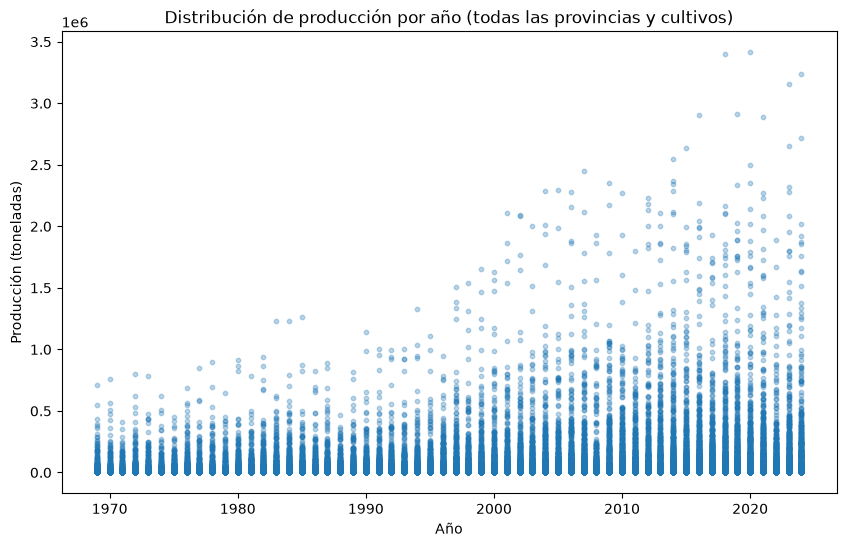

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df['anio'], df['produccion_tm'], alpha=0.3, s=10)
plt.xlabel('Año')
plt.ylabel('Producción (toneladas)')
plt.title('Distribución de producción por año (todas las provincias y cultivos)')
plt.show()

Hay una tendencia creciente clara — a partir de 1990-2000, empiezan a aparecer valores mucho más altos (2, 3 millones de toneladas) que casi no existían antes. Una regresión lineal sí va a poder capturar algo de esto — no es una locura usarla.

Pero hay muchísima dispersión — mirá que para un mismo año (por ejemplo, 2020), hay puntos desde casi 0 hasta 3 millones. Eso tiene una explicación,estan mezclando 23 provincias y 3 cultivos distintos en el mismo gráfico. Buenos Aires en 2020 produce muchísimo, Santa Cruz casi nada — por eso la nube es tan ancha en el eje vertical.

La "base" de puntos pegados al 0 en todos los años son las provincias chicas (Santa Cruz, Mendoza, etc.) que casi no producen estos cultivos, sin importar el año — el crecimiento real está concentrado en pocas provincias grandes.

### 5. Entrenar el modelo de regresión lineal

Aquí entrenamos el modelo con los datos de entrenamiento.

In [6]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Modelo entrenado")

Modelo entrenado


### 6. Generar predicciones

Usamos el modelo entrenado para predecir valores sobre los datos de prueba.

In [7]:
predicciones = modelo.predict(X_test)

predicciones[:10]

array([149492.60923806, 181668.71535717,  75036.39719646, 110633.08509602,
        57573.74171908, 105876.50109341,  52156.14275599,  56637.89422444,
       -43129.54198005,  23608.55386893])

### 7. Comparar valores reales y predichos

Mostramos una muestra de la comparación entre lo que el modelo predijo y lo que realmente ocurrió.

In [8]:
comparacion = pd.DataFrame({
    'real': y_test,
    'prediccion': predicciones
})

comparacion.head(10)

,real,prediccion
4615,72000,149492.609238
2969,59990,181668.715357
13559,45540,75036.397196
42673,2800,110633.085096
35486,58300,57573.741719
39385,723387,105876.501093
23602,2200,52156.142756
40074,990,56637.894224
32251,3,-43129.541980
11126,336,23608.553869


### 8. Evaluar el rendimiento del modelo

Calculamos métricas como MAE y R² para medir qué tan bien está funcionando el modelo.

In [9]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)

print(f"Error promedio (MAE): {mae:,.0f} toneladas")
print(f"R² (qué tan bien explica el modelo): {r2:.3f}")

Error promedio (MAE): 79,266 toneladas
R² (qué tan bien explica el modelo): 0.198


### Regresión lineal simple — Predicción de producción agrícola

Se entrenó un modelo de regresión lineal usando `año` y `provincia` (one-hot encoding) para 
predecir la producción en toneladas, sobre los 3 cultivos analizados (soja, maíz, trigo) y 
las 23 provincias en conjunto.

**Resultado:** MAE de ~79.266 toneladas y R² de 0.198 — el modelo explica solo ~20% de la 
variación real, un desempeño pobre.

**Diagnóstico:** la regresión lineal asume una relación simple entre las variables y el 
resultado, pero la escala de producción varía enormemente entre provincias (de unas pocas 
toneladas a millones), y esa relación no es lineal. El modelo termina promediando de forma 
que no representa bien ni a las provincias grandes ni a las chicas — incluso llegó a predecir 
valores negativos, algo imposible en la realidad.

**Próximos pasos posibles:** entrenar un modelo no lineal (ej. Random Forest), separar el análisis por provincia, o incorporar el cultivo como feature adicional.

## Random Forest — Segundo intento de predicción

La regresión lineal simple funcionó mal (R² de 0.198) porque asume una relación lineal entre 
las variables y el resultado, algo que no se ajusta bien a la enorme variación de escala entre 
provincias. Probamos ahora un **Random Forest**: un modelo que entrena cientos de árboles de 
decisión distintos y promedia sus resultados, capaz de capturar relaciones más complejas y 
no lineales entre `año`, `provincia` y `producción`.

In [10]:
from sklearn.ensemble import RandomForestRegressor

modelo_bosque = RandomForestRegressor(random_state=42)
modelo_bosque.fit(X_train, y_train)

predicciones_bosque = modelo_bosque.predict(X_test)

mae_bosque = mean_absolute_error(y_test, predicciones_bosque)
r2_bosque = r2_score(y_test, predicciones_bosque)

print(f"Error promedio (MAE): {mae_bosque:,.0f} toneladas")
print(f"R² (qué tan bien explica el modelo): {r2_bosque:.3f}")

Error promedio (MAE): 69,120 toneladas
R² (qué tan bien explica el modelo): 0.249


### Random Forest — Resultado

**Resultado:** MAE de ~69.120 toneladas y R² de 0.249.

**Comparación con la regresión lineal:**

| Métrica | Regresión lineal | Random Forest |
|---|---|---|
| MAE | 79.266 tn | 69.120 tn |
| R² | 0.198 | 0.249 |

El Random Forest mejora sobre la regresión lineal (menor error, mayor R²), confirmando que 
un modelo no lineal captura mejor la relación entre las variables. Sin embargo, la mejora es 
moderada — con R² de 0.249, el modelo sigue explicando menos del 25% de la variación real, 
lo cual sigue siendo un desempeño débil para uso práctico.

**Diagnóstico:** el problema de fondo no es solo el tipo de modelo, sino las variables 
utilizadas. `año` y `provincia` por sí solas no alcanzan para explicar bien la producción — 
factores como el cultivo, el departamento específico, o variables climáticas (no disponibles 
en este dataset) probablemente tengan más peso real en la producción que el año en sí.

**Próximos pasos posibles:** incorporar `cultivo` como feature adicional, o entrenar modelos 
separados por provincia en vez de uno conjunto.

##  Random Forest + cultivo — Tercer intento de predicción

In [11]:
# Esta vez incluimos también 'cultivo' en las features
X_v2 = df[['anio', 'provincia', 'cultivo']]

X_v2_codificado = pd.get_dummies(X_v2, columns=['provincia', 'cultivo'])

X_v2_codificado.head()

,anio,provincia_Buenos Aires,provincia_Catamarca,provincia_Chaco,provincia_Chubut,provincia_Corrientes,provincia_Córdoba,provincia_Entre Ríos,provincia_Formosa,provincia_Jujuy,...,provincia_Salta,provincia_San Juan,provincia_San Luis,provincia_Santa Cruz,provincia_Santa Fe,provincia_Santiago del Estero,provincia_Tucumán,cultivo_maíz,cultivo_soja total,cultivo_trigo total
0,1969,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,1969,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,1969,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,1969,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,1969,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [12]:
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_v2_codificado, y, test_size=0.2, random_state=42)

In [13]:
modelo_bosque_v2 = RandomForestRegressor(random_state=42)
modelo_bosque_v2.fit(X_train_v2, y_train_v2)

predicciones_v2 = modelo_bosque_v2.predict(X_test_v2)

mae_v2 = mean_absolute_error(y_test_v2, predicciones_v2)
r2_v2 = r2_score(y_test_v2, predicciones_v2)

print(f"Error promedio (MAE): {mae_v2:,.0f} toneladas")
print(f"R² (qué tan bien explica el modelo): {r2_v2:.3f}")

Error promedio (MAE): 63,016 toneladas
R² (qué tan bien explica el modelo): 0.324


###  Random Forest + cultivo — Resultado

**Resultado:** MAE de ~63.016 toneladas y R² de 0.324.

**Comparación de los 3 modelos:**

| Modelo | Features | MAE | R² |
|---|---|---|---|
| Regresión lineal | año + provincia | 79.266 tn | 0.198 |
| Random Forest | año + provincia | 69.120 tn | 0.249 |
| Random Forest | año + provincia + cultivo | 63.016 tn | 0.324 |

Agregar `cultivo` como feature mejoró el modelo de forma más notoria que el cambio de 
regresión lineal a Random Forest — confirma que el tipo de cultivo es una variable con más 
poder explicativo que el tipo de modelo usado. Con R² de 0.324, el modelo ahora explica 
casi un tercio de la variación real, todavía lejos de un modelo "bueno" para uso práctico, 
pero con una mejora progresiva y coherente en cada iteración.

**Conclusión general del ejercicio:** la producción agrícola depende de muchos factores no capturados en este dataset (clima, precio internacional, tecnología aplicada, tipo de suelo), por lo que un modelo basado solo en año, provincia y cultivo tiene un techo de precisión limitado — algo esperable y coherente con el objetivo de este ejercicio, que era aprender el flujo completo de Machine Learning (entrenar, medir, diagnosticar, iterar) más que lograr un modelo de producción real.

## Cuarto intento — Modelo acotado a las provincias líderes en producción

Los intentos anteriores mezclaron las 23 provincias en un mismo modelo, incluyendo muchas con producción casi nula — esto le agrega "ruido" al aprendizaje, porque el modelo tiene que lidiar con escalas extremadamente distintas al mismo tiempo. Probamos ahora acotar el problema a las 5 provincias líderes en producción (Buenos Aires, Córdoba, Santa Fe, Entre 
Ríos, Santiago del Estero), para ver si un dataset más homogéneo mejora la capacidad predictiva del modelo.

In [14]:
provincias_top = ['Buenos Aires', 'Córdoba', 'Santa Fe', 'Entre Ríos', 'Santiago del Estero']

df_top = df[df['provincia'].isin(provincias_top)]

df_top.shape

(26918, 11)

In [16]:
X_top = df_top[['anio', 'provincia', 'cultivo']]
y_top = df_top['produccion_tm']

X_top_codificado = pd.get_dummies(X_top, columns=['provincia', 'cultivo'])

x_train_top, X_test_top, y_train_top, y_test_top = train_test_split(X_top_codificado, y_top, test_size=0.2, random_state=42)

modelo_top = RandomForestRegressor(random_state=42)
modelo_top.fit(x_train_top, y_train_top)

predicciones_top = modelo_top.predict(X_test_top)

mea_top = mean_absolute_error(y_test_top, predicciones_top)
r2_top = r2_score(y_test_top, predicciones_top)

print(f"Error promedio (MAE): {mea_top:,.0f} toneladas")
print(f"R² (qué tan bien explica el modelo): {r2_top:.3f}")



Error promedio (MAE): 95,832 toneladas
R² (qué tan bien explica el modelo): 0.246


### Resultado — Modelo acotado a provincias líderes

**Resultado:** MAE de ~95.832 toneladas y R² de 0.246.

**Comparación:** el MAE aumentó respecto al modelo anterior, pero es un efecto esperado de 
la escala (las provincias líderes manejan volúmenes mucho mayores, por lo que el error 
absoluto en toneladas también crece). El R² es la métrica más justa para comparar acá, y 
se mantuvo prácticamente igual (0.246 vs. 0.324 del modelo con las 23 provincias) — incluso 
levemente peor.

**Conclusión:** la hipótesis de que mezclar provincias de escalas muy distintas era el 
problema principal no se confirma. El techo de precisión del modelo parece estar dado, más 
bien, por la falta de variables realmente explicativas (clima, tecnología, precio 
internacional) que no están disponibles en este dataset — ni acotar el grupo de provincias 
ni cambiar de modelo lineal a Random Forest lograron una mejora sustancial.

#  Conclusión general — Primer proyecto de Machine Learning

## Objetivo del ejercicio

Aprender el flujo completo de Machine Learning (separar datos, entrenar, medir, diagnosticar 
e iterar) aplicándolo a un dataset ya conocido: la producción agrícola por provincia del 
proyecto de trazabilidad agroexportadora. El objetivo no era lograr un modelo listo para 
producción, sino entender de punta a punta cómo se construye y evalúa uno.

## Resumen de los 4 modelos entrenados

| # | Modelo | Features | MAE | R² |
|---|---|---|---|---|
| 1 | Regresión lineal | año + provincia | 79.266 tn | 0.198 |
| 2 | Random Forest | año + provincia | 69.120 tn | 0.249 |
| 3 | Random Forest | año + provincia + cultivo | 63.016 tn | 0.324 |
| 4 | Random Forest | año + provincia + cultivo (solo top 5 provincias) | 95.832 tn | 0.246 |

## Qué se aprendió en cada paso

- **One-hot encoding:** cómo convertir variables categóricas (provincia, cultivo) en algo 
  que un modelo numérico pueda procesar, sin introducir un orden falso entre categorías.
- **Train/test split:** por qué es indispensable evaluar un modelo con datos que nunca vio, 
  para saber si realmente "aprendió" un patrón o solo memorizó.
- **Comparación de modelos:** un modelo no lineal (Random Forest) superó a uno lineal, 
  confirmando que la relación entre las variables y la producción no es una simple recta.
- **El poder de las features por sobre el modelo:** agregar `cultivo` mejoró más el 
  resultado que cambiar de algoritmo — la calidad y relevancia de las variables de entrada 
  suele pesar más que la sofisticación del modelo elegido.
- **Cuando una hipótesis "obvia" no se confirma:** acotar el análisis a las provincias 
  líderes no mejoró el R², revelando que el techo de precisión no estaba en la mezcla de 
  escalas entre provincias, sino en la falta de variables realmente explicativas.

## Por qué el modelo no llegó a un R² alto (y por qué está bien que así sea)

Ninguna de las variables disponibles en este dataset (año, provincia, cultivo) captura los 
factores que más influyen en la producción agrícola real: condiciones climáticas de cada 
campaña, adopción de tecnología, precio internacional del cultivo, tipo de suelo. Un modelo 
solo puede ser tan bueno como la información que se le da — este ejercicio deja claro que 
la selección de datos de entrada (feature engineering) es tan importante, o más, que la 
elección del algoritmo.

## Próximos pasos posibles (para un futuro proyecto de ML más ambicioso)

- Incorporar datos climáticos históricos por provincia/campaña
- Usar variables económicas (precio internacional de la soja, tipo de cambio)
- Probar modelos de series temporales (pensados específicamente para datos con evolución 
  en el tiempo, a diferencia de Random Forest que no tiene noción de "orden temporal")